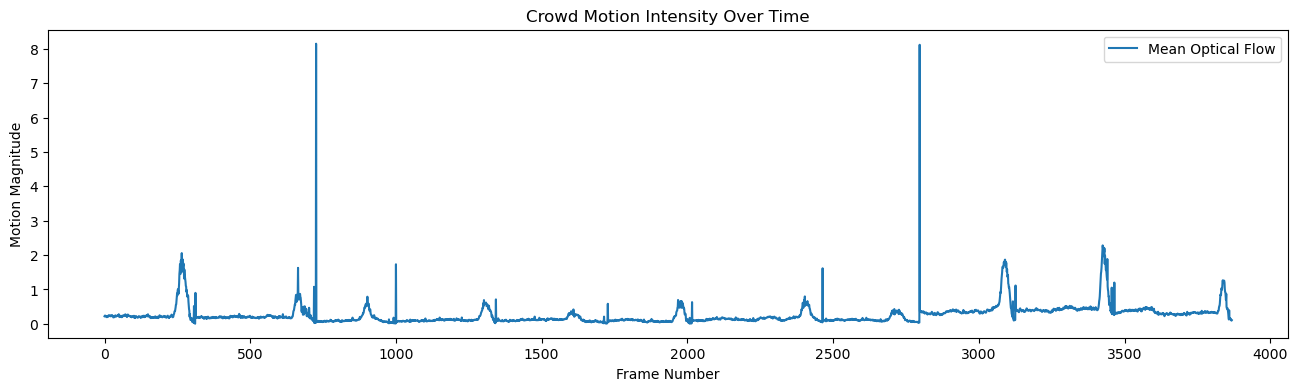

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import confusion_matrix
import time

data = np.load("motion_features.npy")

frames = data[:, 0]
mean_motion = data[:, 1]
var_motion = data[:, 2]

plt.figure(figsize=(16, 4))
plt.plot(frames, mean_motion, label="Mean Optical Flow")
plt.xlabel("Frame Number")
plt.ylabel("Motion Magnitude")
plt.title("Crowd Motion Intensity Over Time")
plt.legend()
plt.show()


In [60]:
normal_mask = mean_motion < np.percentile(mean_motion, 25)
normal_features = data[normal_mask][:, 1:]

In [61]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor

scaler = MinMaxScaler()
normal_scaled = scaler.fit_transform(normal_features)

autoencoder = MLPRegressor(
    hidden_layer_sizes=(8, 4),
    activation='relu',
    max_iter=800,
    random_state=42
)

autoencoder.fit(normal_scaled, normal_scaled)

MLPRegressor(hidden_layer_sizes=(8, 4), max_iter=800, random_state=42)

In [62]:
normal_recon = autoencoder.predict(normal_scaled)
normal_error = np.mean((normal_scaled - normal_recon) ** 2, axis=1)

low_thr = np.percentile(normal_error, 95)
high_thr = np.percentile(normal_error, 99.5)

print("LOW/MEDIUM threshold:", low_thr)
print("MEDIUM/HIGH threshold:", high_thr)


LOW/MEDIUM threshold: 0.08192042185092525
MEDIUM/HIGH threshold: 0.1303774657552377


In [63]:
all_features = scaler.transform(data[:, 1:])
recon_all = autoencoder.predict(all_features)
error_all = np.mean((all_features - recon_all) ** 2, axis=1)


In [64]:
EVENT_WINDOW = 30  # 1 second at 15 FPS

event_pred = np.zeros(len(predicted_labels))
count = 0

for i, val in enumerate(predicted_labels):
    if val == 1:
        count += 1
        if count >= EVENT_WINDOW:
            event_pred[i] = 1
    else:
        count = 0


In [65]:
risk_levels = []

for e in smoothed_error:
    if e > high_thr:
        risk_levels.append("HIGH")
    elif e > low_thr:
        risk_levels.append("MEDIUM")
    else:
        risk_levels.append("LOW")


In [69]:
def frame_to_timestamp(frame_id, fps):
    total_seconds = int(frame_id / fps)
    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    seconds = total_seconds % 60
    return f"{hours:02d}:{minutes:02d}:{seconds:02d}"


In [70]:
FPS = 15
MIN_CONSEC_FRAMES = 30  # persistence window

counter = 0

for i, risk in enumerate(risk_levels):
    if risk == "HIGH":
        counter += 1
        if counter == MIN_CONSEC_FRAMES:
            timestamp = frame_to_timestamp(frames[i], FPS)
            print(f"""
🚨 ALERT
------------------------
Time: {timestamp}
Frame: {int(frames[i])}
Risk Level: HIGH
Cause: Sustained abnormal crowd motion
------------------------
""")
    else:
        counter = 0



🚨 ALERT
------------------------
Time: 00:00:01
Frame: 29
Risk Level: HIGH
Cause: Sustained abnormal crowd motion
------------------------


🚨 ALERT
------------------------
Time: 00:00:59
Frame: 899
Risk Level: HIGH
Cause: Sustained abnormal crowd motion
------------------------


🚨 ALERT
------------------------
Time: 00:01:26
Frame: 1301
Risk Level: HIGH
Cause: Sustained abnormal crowd motion
------------------------


🚨 ALERT
------------------------
Time: 00:01:38
Frame: 1477
Risk Level: HIGH
Cause: Sustained abnormal crowd motion
------------------------


🚨 ALERT
------------------------
Time: 00:01:43
Frame: 1546
Risk Level: HIGH
Cause: Sustained abnormal crowd motion
------------------------


🚨 ALERT
------------------------
Time: 00:02:11
Frame: 1978
Risk Level: HIGH
Cause: Sustained abnormal crowd motion
------------------------


🚨 ALERT
------------------------
Time: 00:02:19
Frame: 2096
Risk Level: HIGH
Cause: Sustained abnormal crowd motion
------------------------


🚨

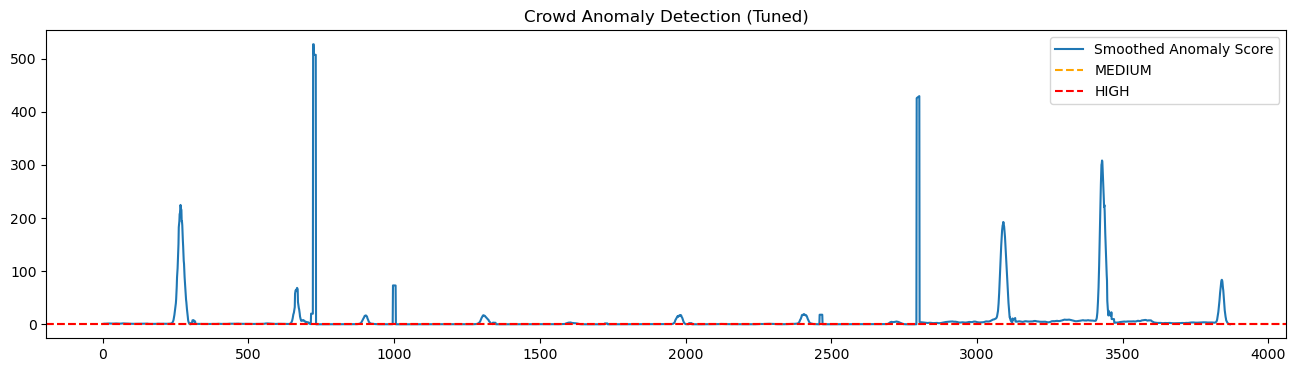

In [74]:
plt.figure(figsize=(16,4))
plt.plot(smoothed_error, label="Smoothed Anomaly Score")
plt.axhline(low_thr, color='orange', linestyle='--', label="MEDIUM")
plt.axhline(high_thr, color='red', linestyle='--', label="HIGH")
plt.legend()
plt.title("Crowd Anomaly Detection (Tuned)")
plt.show()


In [72]:
predicted_labels = np.array([
    1 if r == "HIGH" else 0
    for r in risk_levels
])


true_labels = np.zeros(len(mean_motion))
true_labels[mean_motion > np.percentile(mean_motion, 70)] = 1

tn, fp, fn, tp = confusion_matrix(true_labels, event_pred).ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
false_alert_rate = fp / (fp + tn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"False Alert Rate: {false_alert_rate*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")



Accuracy: 67.43%
False Alert Rate: 43.87%
Precision: 0.48
Recall: 0.94
